# Working with lightcone data - maps and objects

This tutorial compares lightcone halos around redshift 1.45 to a projected density map over the same redshift range, both with visual inspection and a more quantitative correlation coefficent. Let's get started!


In [101]:
import numpy as np
from scipy.spatial import cKDTree # for matching
from matplotlib import pyplot as plt # for plotting 
from matplotlib.colors import LogNorm
from scipy.stats import binned_statistic_2d
import healpy as hp
import healsparse as hsp
from scipy.interpolate import griddata
from astropy.coordinates import SkyCoord
import astropy.units as u



import opencosmo

The API for the map class can be found here https://opencosmo.readthedocs.io/en/stable/collections.html#healpix-maps, but let's play around with it a bit. 

First let's read in the density map, and have a look at some of the more important properties. In particular we should look at the nside, and make sure your machine has enough memory to look at maps like this. If not we can downgrade with the 

```
dataset.with_resolution(new_nside)
```
command, which will downgrade and update the metadata accordingly

In [4]:
dataset = opencosmo.open('filtered_map.hdf5')

# we can get descriptions of the quantities available
print(dataset.descriptions, '\n')

# we can see the resolution of the map
print('resolution is nside = ', dataset.nside, '\n')

# the redshift range
print('redshift range = ', dataset.z_range, '\n')

# and the ordering
print('ordering = ', dataset.ordering, '\n')

# and the cosmology
print('cosmology = ', dataset.cosmology)

{'rho': 'Total matter density in shell'} 

resolution is nside =  4096 

redshift range =  (1.405457156534227, 1.4814814814814818) 

ordering =  NESTED 

cosmology =  FlatLambdaCDM(H0=67.66 km / (Mpc s), Om0=0.3096446816186967, Tcmb0=0.0 K, Neff=3.04, m_nu=None, Ob0=0.04897468161869667)


### Loading the map 

To load the data we use the `get_data` command as usual, but this time we have the option of "healpix", which returns the data as a numpy array, or "healsparse" which returns it as a healpix sparse map. Looking at this you can see that the values are pretty high! This is because the units are in solar masses per steradian divided by little h, which gives pretty extreme numbers. 

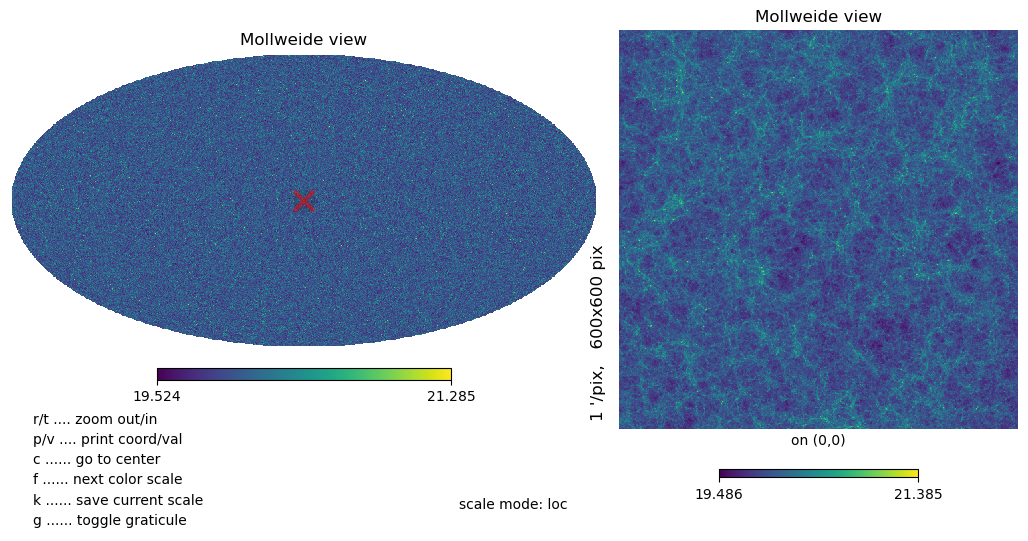

In [102]:
data = dataset.get_data('healpix')
hp.mollzoom(np.log10(data['rho']), nest=True)
rho_mean = np.nanmean(data['rho'])

### Small cutouts

If we want to zoom in to a specific area around a halo we can do that using the cone search method and it returns a healsparse map that we can look at. You can treat it as a normal HealSparse map and use the native healsparse methods at this point. I'm going to quickly visualize the cutout area. 

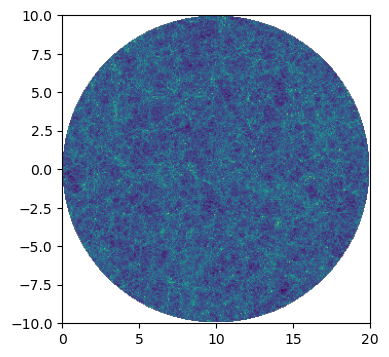

In [105]:
cx = 10 # center RA point in degrees 
cy = 0 # center declination point in degrees
dx = 10 # radius in degrees
dtheta = np.cos( cy*np.pi/180)

data_cutout = dataset.cone_search((cx,cy), dx)

# the data is now returned as a HealSparse map due to the truncation 
data_rho = data_cutout.get_data()['rho']

# If we want the data and pixel locations we can do this using the healsparse method valid_pixel_pos
vpix, ra, dec = data_rho.valid_pixels_pos(return_pixels=True)
ra_wrap = ((ra - cx + 180) % 360) - 180 + cx # wrap RA units so griddata can understand them

# Quick plotting method
npoints = 300j
grid_x, grid_y = np.mgrid[cx-dx/dtheta:cx+dx/dtheta:npoints, cy-dx:cy+dx:npoints]
zi = griddata((ra_wrap, dec), np.log10(data_rho[vpix]), (grid_x, grid_y), method='cubic')

plt.figure(figsize=(4,4))
plt.imshow(zi.T, extent=(cx-dx/dtheta,cx+dx/dtheta,cy-dx,cy+dx), origin='lower', aspect=1./np.cos(np.deg2rad(cy))) # altering the aspect so we get a square


### Reading in the halos

I've queried the halo lightcone data on the same redshift slice as the map is built on so we can directly compare the two. We don't natively have an RA or dec column, so we'll start by creating one using the `with_new_colums` method. See the full details of creating new columns here: https://opencosmo.readthedocs.io/en/stable/cols.html. 


In [106]:
def radec_fromthetaphi(theta,phi):
    ra = phi
    dec = 90. - theta 
    return ra,dec

def thetaphi_fromradec(ra,dec):
    phi = ra 
    theta = 90.  - dec
    return theta, phi



dataset_halos = opencosmo.open('filtered_haloproperties.hdf5')

fof_halo_ra, fof_halo_dec = radec_fromthetaphi(opencosmo.col("theta")*180./np.pi, opencosmo.col("phi")*180./np.pi)

dataset_halos = dataset_halos.with_new_columns(ra = fof_halo_ra)
dataset_halos = dataset_halos.with_new_columns(dec = fof_halo_dec)


column_list = ['fof_halo_mass', 'fof_halo_center_x', 'fof_halo_center_y',
               'fof_halo_center_z', 'fof_halo_tag', 'redshift', 'ra',
               'dec','theta','phi']


dataset_halos = dataset_halos.select(column_list)

### Inspecting the halos and map

We can then apply the exact same selection we made to the map, and create a histogram of the halos to compare to our density map. Side by side they look pretty similar! 

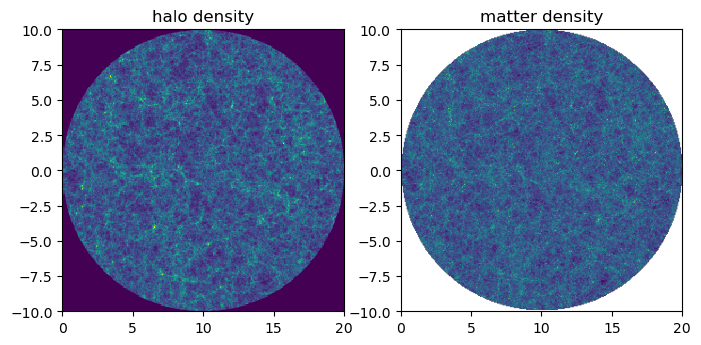

In [113]:
region = opencosmo.make_cone((cx,cy),dx)
dataset_halos = dataset_halos.bound(region)
data_halos = dataset_halos.get_data('numpy')


fig, ax = plt.subplots(1, 2, figsize=(8,4))

ax[0].hist2d( data_halos['ra'], data_halos['dec'], bins=(np.linspace(cx-dx/dtheta, cx+dx/dtheta, nbins), np.linspace(cy-dx, cy+dx, nbins)))
ax[1].imshow(zi.T, extent=(cx-dx/dtheta,cx+dx/dtheta,cy-dx,cy+dx), origin='lower')
ax[0].set_title('halo density')
ax[1].set_title('matter density')
for a in ax:
    a.set_aspect('equal')
plt.show()



## Cross-correlating the overdensity and the halo data 

We can quantify this by cross-correlating these maps using `treecorr`. We first need to create a set of randoms to compare to the halo objects. We're just going to create a rectangle then cut it using the same method that opencosmo uses under the hood. 

In [121]:

def get_randoms(cx,dx,data_halos):
    ra_min = cx - dx*2 
    ra_max = cx + dx*2
    dec_min = cy - dx*2
    dec_max = cy + dx*2
    N= len(data_halos['ra']) * 10

    ra_rand = np.random.uniform(ra_min, ra_max, N)
    sin_dec_rand = np.random.uniform(
        np.sin(np.deg2rad(dec_min)),
        np.sin(np.deg2rad(dec_max)),
        N
    )
    dec_rand = np.rad2deg(np.arcsin(sin_dec_rand))
    center = SkyCoord(cx*u.deg, cy*u.deg)
    rand_coords = SkyCoord(ra_rand*u.deg, dec_rand*u.deg)
    mask = rand_coords.separation(center) < dx*u.deg
    ra_rand = ra_rand[mask]
    dec_rand = dec_rand[mask]
    return ra_rand, dec_rand

ra_rand, dec_rand = get_randoms(cx,dx,data_halos)


And then we can create the `treecorr` catalogs. We're converting the map into an overdensity to get rid of those pesky large numbers, and limiting ourselves to small-ish scales that are covered by the mask. 

In [125]:

hcat = treecorr.Catalog(ra=data_halos['ra'], dec=data_halos['dec'], ra_units='deg', dec_units='deg')
mcat = treecorr.Catalog(ra=ra, dec=dec, ra_units='deg', dec_units='deg', k=(data_rho[vpix]- rho_mean)/rho_mean)
randcat = treecorr.Catalog(ra=ra_rand, dec=dec_rand, ra_units='deg', dec_units='deg')

# Measure N-K correlation
nk = treecorr.NKCorrelation(nbins=20, min_sep=1, max_sep=40, sep_units='arcmin')
nn = treecorr.NNCorrelation(nbins=20, min_sep=1, max_sep=40, sep_units='arcmin')
kk = treecorr.KKCorrelation(nbins=20, min_sep=1, max_sep=40, sep_units='arcmin')
nr = treecorr.NNCorrelation(nbins=20, min_sep=1, max_sep=40, sep_units='arcmin')
rr = treecorr.NNCorrelation(nbins=20, min_sep=1, max_sep=40, sep_units='arcmin')


nk.process(hcat, mcat)
nn.process(hcat, hcat)
kk.process(mcat, mcat)
nr.process(hcat, randcat)
rr.process(randcat, randcat)

# Access results
r = np.exp(nk.meanlogr)
xi_nn, var_nn = nn.calculateXi(rr=rr, dr=nr)
xi_nk = nk.xi # The cross-correlation
xi_kk = kk.xi # The cross-correlation


### Results 

We can see how correlated these fields are using the correlation coefficient. They're not absolutely perfect (halos and dark matter particles aren't exactly the same after all), but the correlation is pretty high as you'd expect. 

This is a rough method designed to demonstrate working with the lightcone data in a practical way, so please don't hold it against me if this field is too small or the mask too weird for an arbitrary correlation measurement! However we can now quantitatively say that our eyes were not lying to us and these fields are pretty similar :)

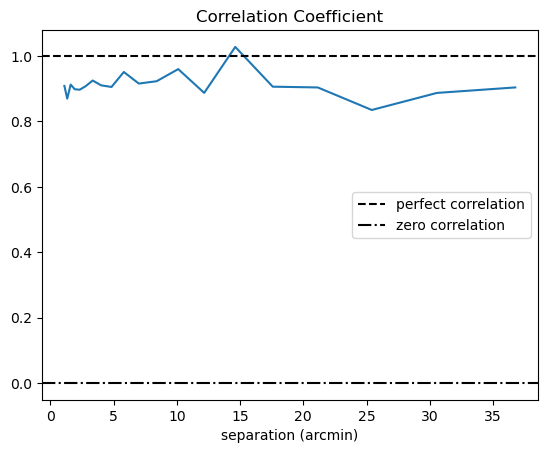

In [126]:
plt.figure()

corr_coef = xi_nk / np.sqrt(xi_nn * xi_kk)

plt.title('Correlation Coefficient')
plt.plot(r, corr_coef)
plt.axhline(1.0, color = 'k', linestyle = '--', label='perfect correlation')
plt.axhline(0.0, color = 'k', linestyle = '-.', label='zero correlation')
plt.xlabel('separation (arcmin)')
#plt.ylim([-10,1])
plt.legend()
plt.show()